In [193]:
#Step 0: Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report, RocCurveDisplay
from sklearn.inspection import permutation_importance
from scipy.stats import boxcox
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [174]:
#Step 1: Load Data
url = '/content/qsar_aquatic_toxicity.csv'
df_raw = pd.read_csv(url, sep=';', header=None)
df_raw.columns = ['TPSA','SAcc','H050','MLOGP','RDCH','GATS1p','nN','C040','LC50']
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546 entries, 0 to 545
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TPSA    546 non-null    float64
 1   SAcc    546 non-null    float64
 2   H050    546 non-null    int64  
 3   MLOGP   546 non-null    float64
 4   RDCH    546 non-null    float64
 5   GATS1p  546 non-null    float64
 6   nN      546 non-null    int64  
 7   C040    546 non-null    int64  
 8   LC50    546 non-null    float64
dtypes: float64(6), int64(3)
memory usage: 38.5 KB


In [175]:
df_raw.sample(10, random_state=2025)

,TPSA,SAcc,H050,MLOGP,RDCH,GATS1p,nN,C040,LC50
240,0.00,0.000,0,6.232,2.728,0.493,0,0,7.610
57,87.66,139.995,3,1.589,3.514,1.339,2,1,3.819
143,83.67,84.184,1,0.349,2.397,2.092,1,1,5.760
493,0.00,0.000,0,3.259,1.979,1.111,0,0,4.300
48,29.10,43.156,1,3.076,2.438,0.773,1,1,4.714
400,111.87,144.177,1,1.748,2.377,0.839,2,0,4.790
424,13.14,9.507,0,3.743,2.995,0.783,0,0,4.737
381,20.23,42.683,1,2.637,2.344,0.758,0,0,4.610
482,110.45,141.047,1,2.767,3.488,1.216,2,2,4.071
475,44.45,16.786,0,1.157,1.334,0.685,1,1,5.418


In [176]:
#Step 2: Preprocessing
df_baking = df_raw.copy()
df_baking.columns = df_baking.columns.str.lower()
df_baking = df_baking.drop_duplicates() #Borra filas duplicadas
#df_baking['lc50'] = df_baking['lc50'].astype('category')
df = df_baking.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546 entries, 0 to 545
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tpsa    546 non-null    float64
 1   sacc    546 non-null    float64
 2   h050    546 non-null    int64  
 3   mlogp   546 non-null    float64
 4   rdch    546 non-null    float64
 5   gats1p  546 non-null    float64
 6   nn      546 non-null    int64  
 7   c040    546 non-null    int64  
 8   lc50    546 non-null    float64
dtypes: float64(6), int64(3)
memory usage: 38.5 KB


In [177]:
df.sample(10, random_state=2025)

,tpsa,sacc,h050,mlogp,rdch,gats1p,nn,c040,lc50
240,0.00,0.000,0,6.232,2.728,0.493,0,0,7.610
57,87.66,139.995,3,1.589,3.514,1.339,2,1,3.819
143,83.67,84.184,1,0.349,2.397,2.092,1,1,5.760
493,0.00,0.000,0,3.259,1.979,1.111,0,0,4.300
48,29.10,43.156,1,3.076,2.438,0.773,1,1,4.714
400,111.87,144.177,1,1.748,2.377,0.839,2,0,4.790
424,13.14,9.507,0,3.743,2.995,0.783,0,0,4.737
381,20.23,42.683,1,2.637,2.344,0.758,0,0,4.610
482,110.45,141.047,1,2.767,3.488,1.216,2,2,4.071
475,44.45,16.786,0,1.157,1.334,0.685,1,1,5.418


In [178]:
#Step3: EDA
df_train, df_test = train_test_split(df, test_size=0.1, random_state=2025)
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_train.shape, df_test.shape

((491, 9), (55, 9))

In [179]:
#Analisis descriptivo
display(df_train.describe(include='number').T)
#display(df_train.describe(include='category').T)


,count,mean,std,min,25%,50%,75%,max
tpsa,491.0,49.007821,47.892908,0.000,14.465,40.460,70.1400,347.320
sacc,491.0,59.858112,70.315322,0.000,11.000,42.683,78.0395,571.952
h050,491.0,0.957230,1.669719,0.000,0.000,0.000,1.0000,18.000
mlogp,491.0,2.318984,1.764460,-6.446,1.237,2.296,3.4775,9.148
rdch,491.0,2.503827,0.819345,1.000,1.975,2.344,2.9300,6.439
gats1p,491.0,1.043798,0.400222,0.281,0.737,1.021,1.2560,2.500
nn,491.0,0.997963,1.407703,0.000,0.000,0.000,2.0000,11.000
c040,491.0,0.358452,0.829202,0.000,0.000,0.000,0.0000,11.000
lc50,491.0,4.666684,1.661448,0.122,3.609,4.530,5.6290,10.047


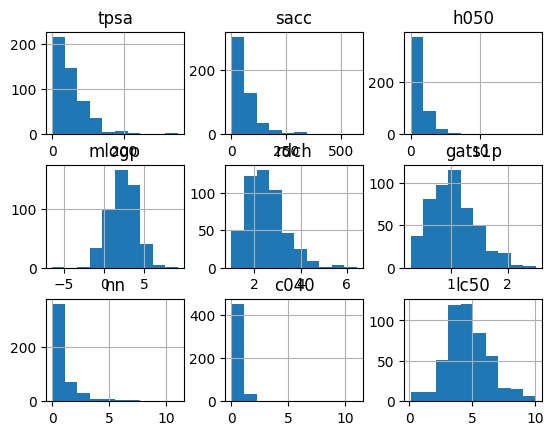

In [180]:
#Análisis univariado
df_train.hist()
plt.tight_layout
plt.show()

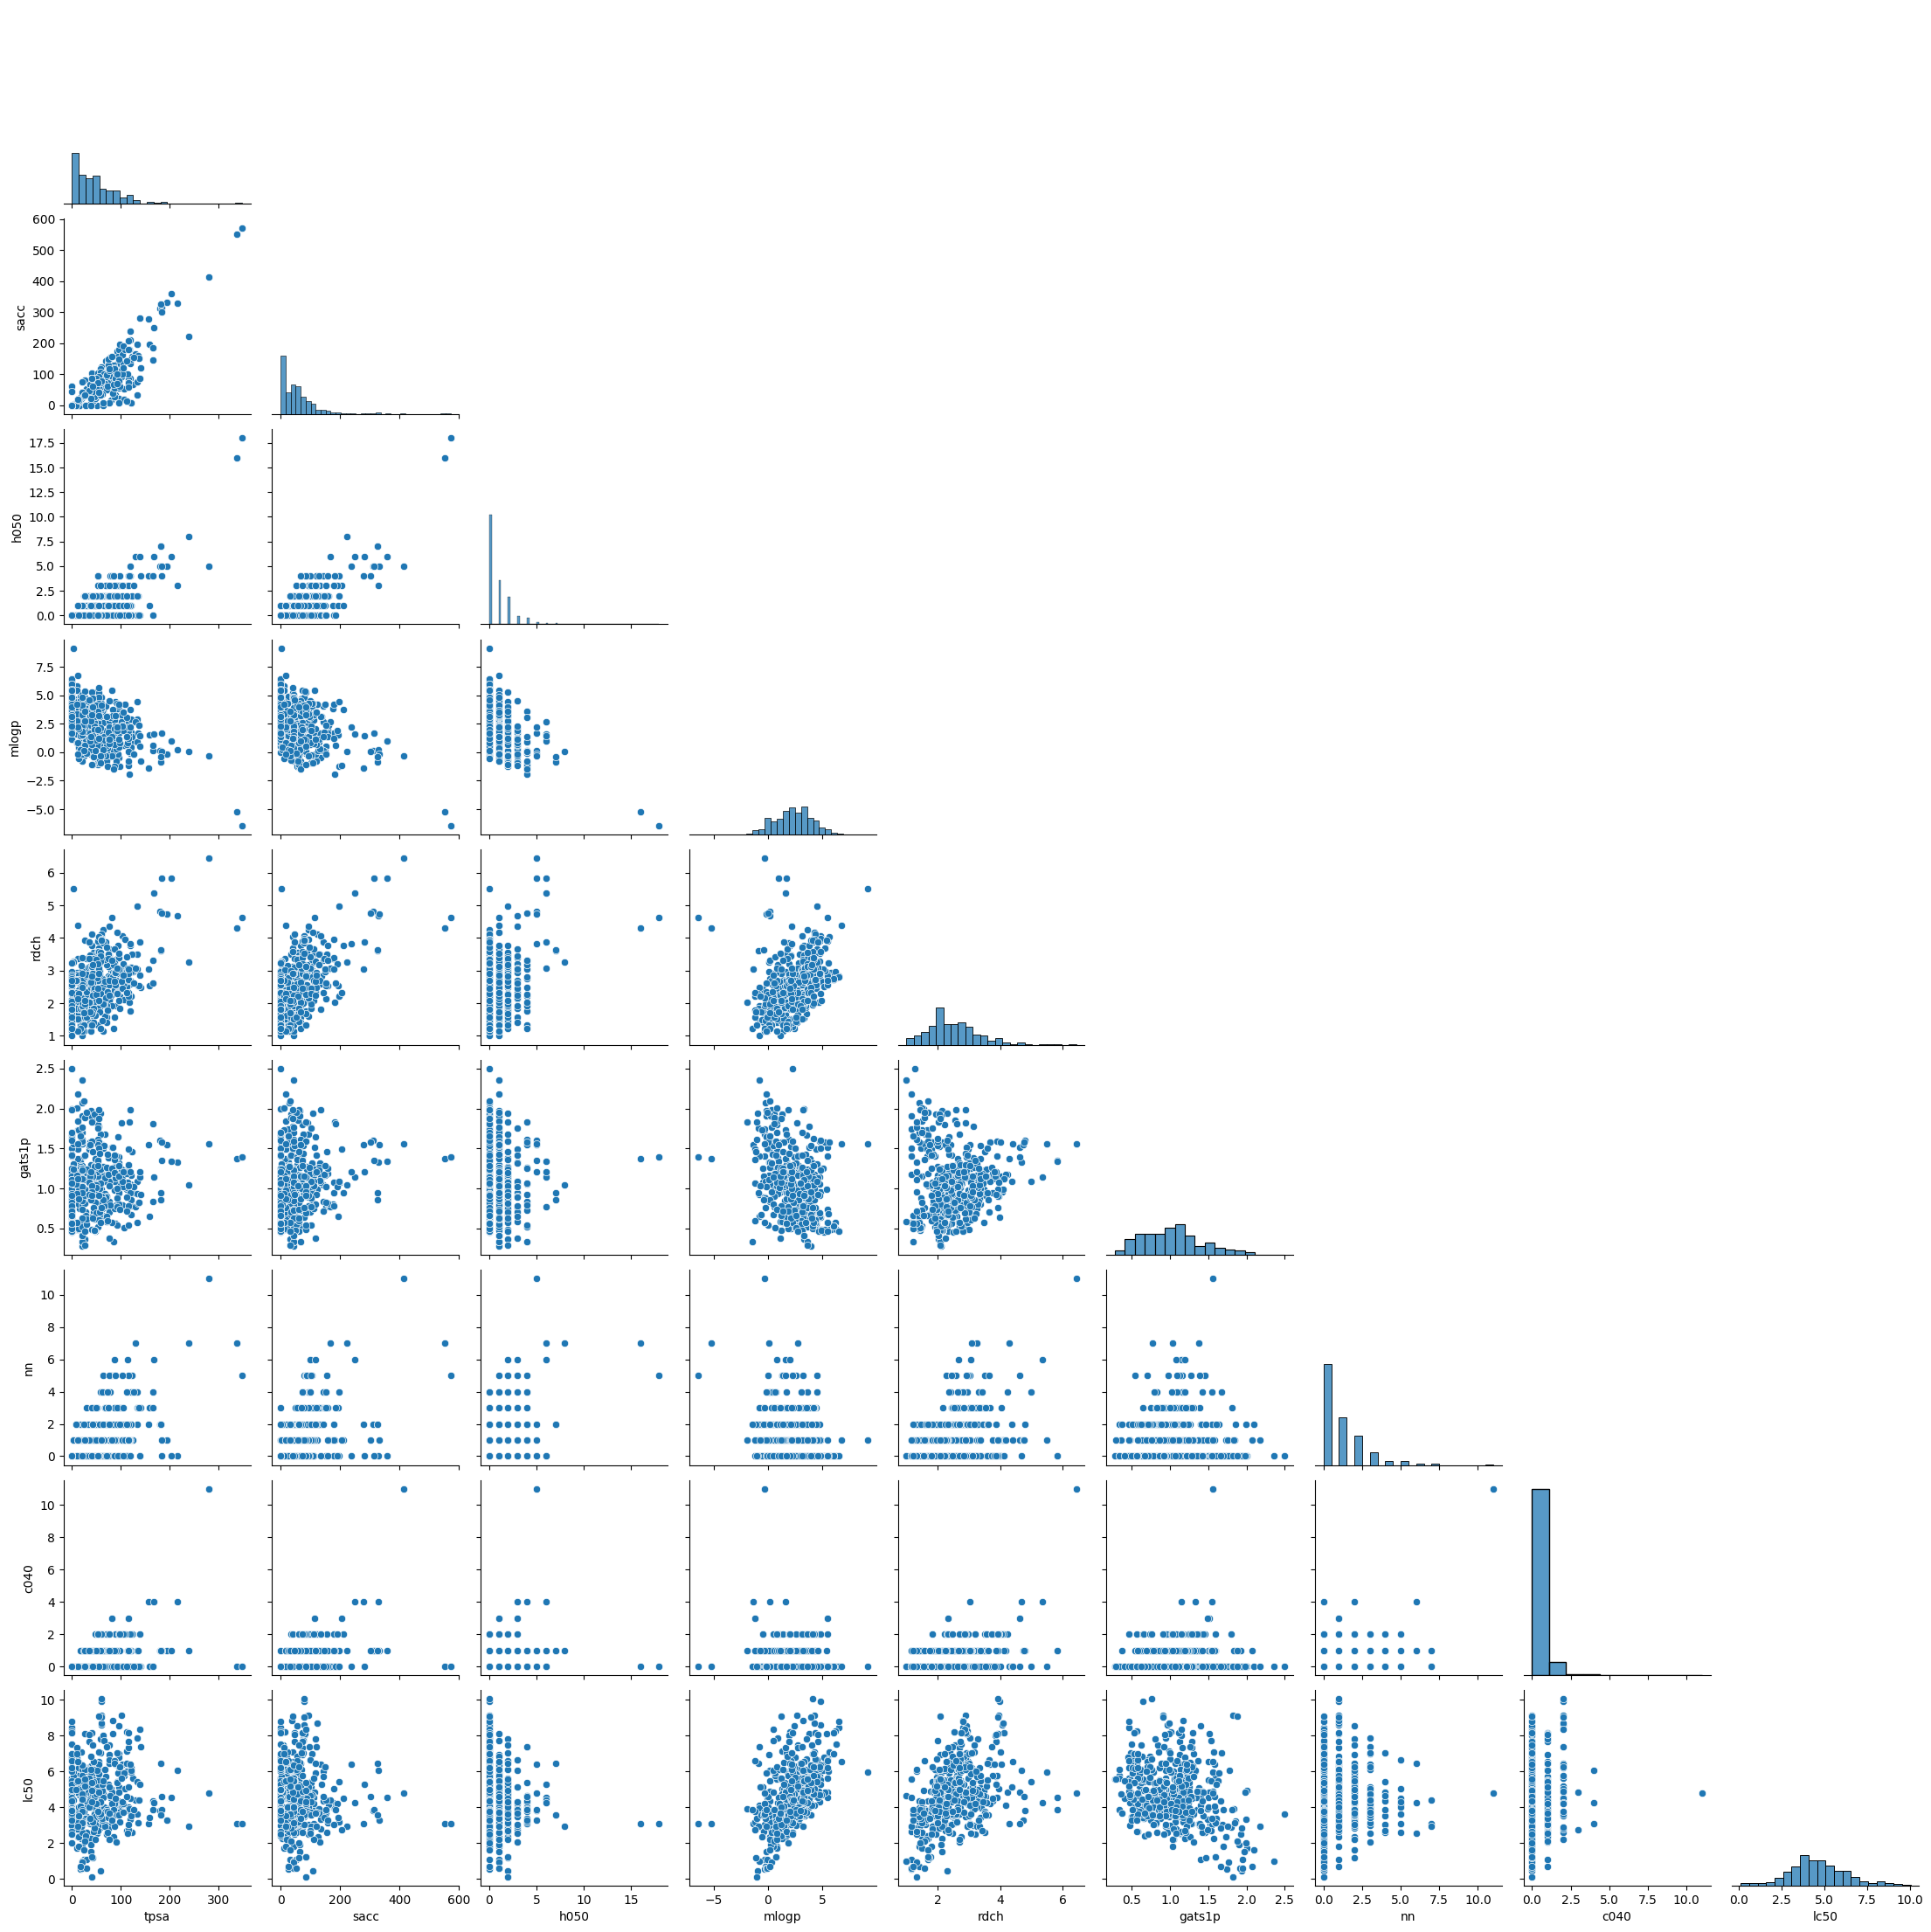

In [181]:
#Análisis univariado
sns.pairplot(df_train, corner=True)
plt.show()

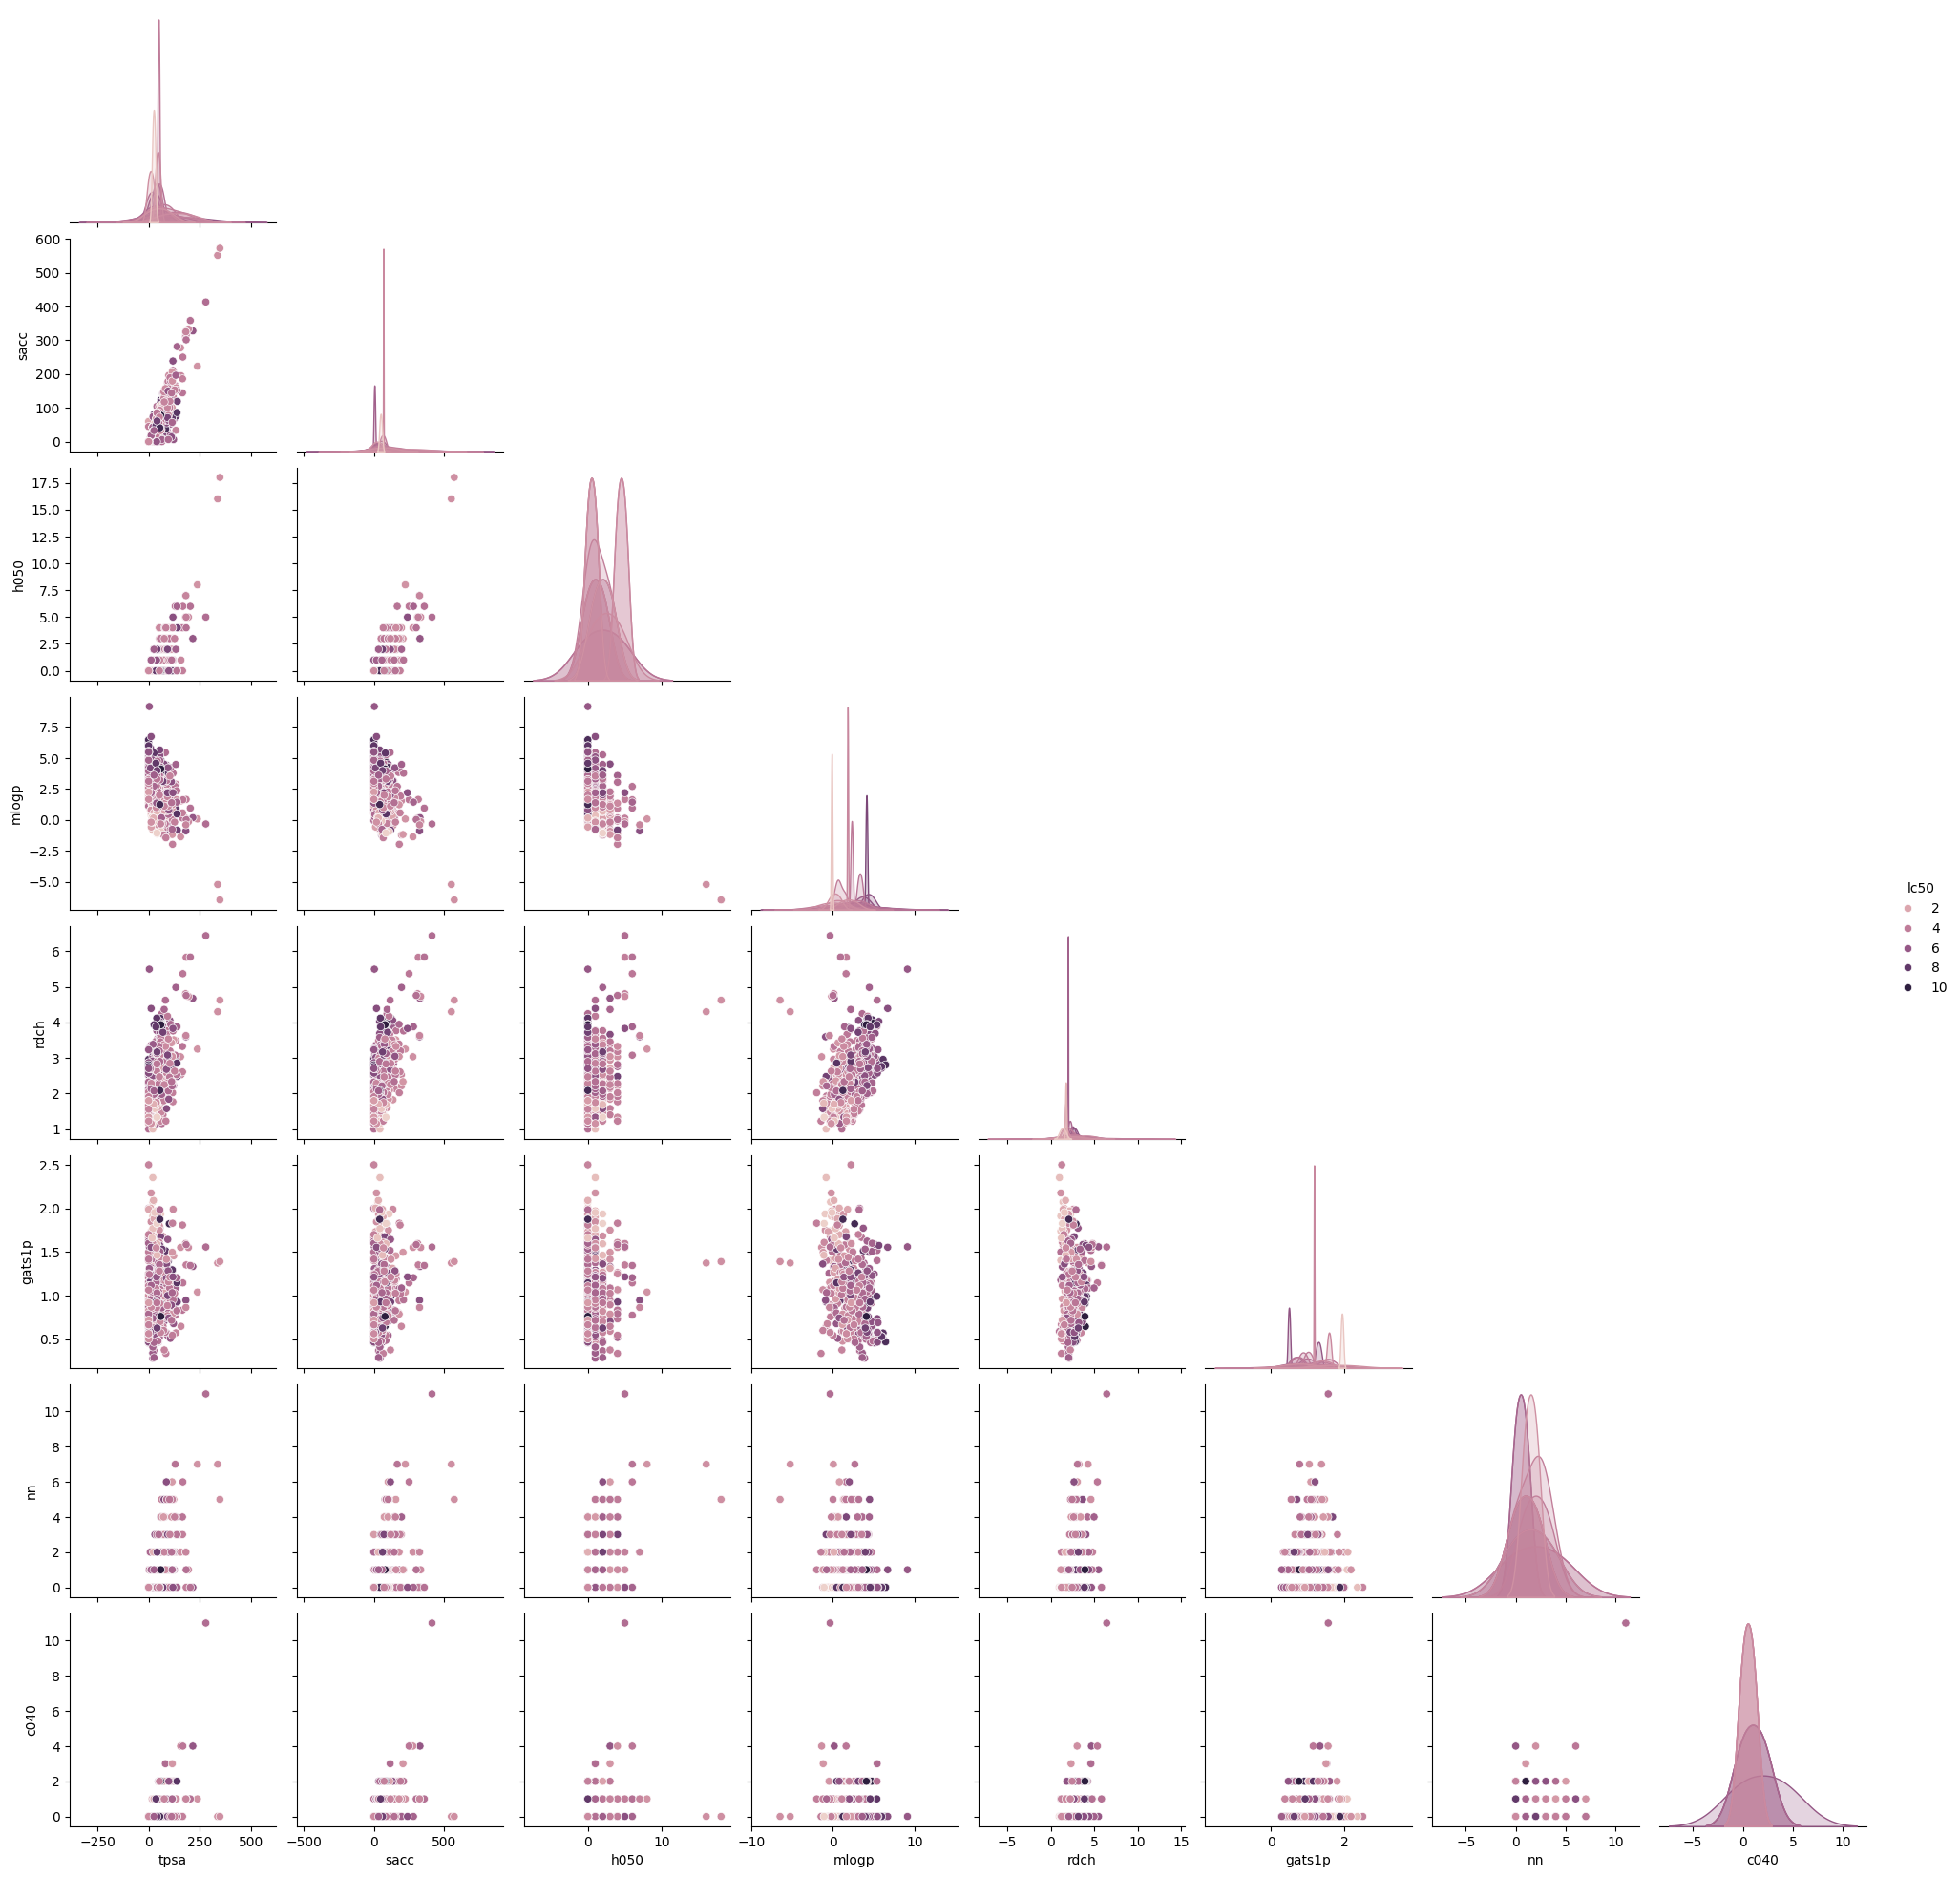

In [182]:
sns.pairplot(df_train, hue='lc50', corner=True)
plt.show()

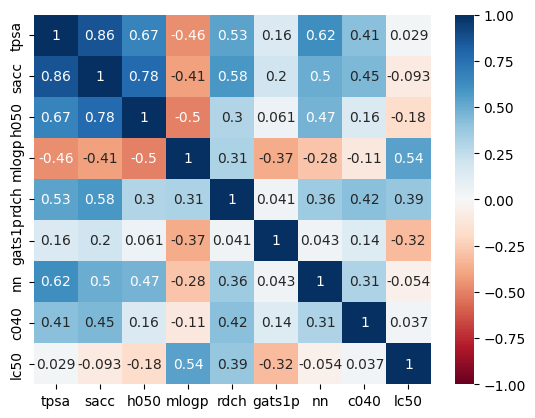

In [183]:
sns.heatmap(df_train.select_dtypes('number').corr(), vmin=-1, vmax=1, cmap='RdBu', annot=True)
plt.show()

In [184]:
#Step 4: ML
#Separar la variable predictora de la variable objetivo
X_train = df_train.drop(columns='lc50')
y_train = df_train['lc50']

X_test = df_test.drop(columns='lc50')
y_test = df_test['lc50']

In [185]:
#Se crea la tuberia
yescols = X_train[['tpsa','sacc','h050','mlogp','rdch','gats1p']].columns #Se tiene que pasar el nombre de las columnas
nocols = X_train[['nn','c040']].columns
box_transformer = Pipeline([
    ('powertrans',PowerTransformer()), # es boxcox
    ('scaler',StandardScaler())
])

nobox_transformer = Pipeline([
    ('scaler', StandardScaler())
])

processor = ColumnTransformer([
    ('yes',box_transformer, yescols),
    ('no', nobox_transformer, nocols)
])

In [201]:
clf_tree = Pipeline([
    ('proc', processor),
    ('tree', DecisionTreeClassifier(class_weight='balanced', random_state=2025))
])

clf_tree.fit(X_train, y_train_enc)

Pipeline(steps=[('proc',
                 ColumnTransformer(transformers=[('yes',
                                                  Pipeline(steps=[('powertrans',
                                                                   PowerTransformer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['tpsa', 'sacc', 'h050', 'mlogp', 'rdch', 'gats1p'], dtype='object')),
                                                 ('no',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['nn', 'c040'], dtype='object'))])),
                ('tree',
                 DecisionTreeClassifier(class_weight='balanced',
                                        random_state=2025))])

In [203]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)  # y_train son floats

RandomForestRegressor(random_state=42)

In [189]:
y_pred = model.predict(X_test)
print(mean_squared_error(y_test, y_pred))

1.4269712267954298


In [210]:
clf_tree_cv = GridSearchCV(
    estimator = clf_tree,
    param_grid = {
        'tree__max_depth':[2,3,4,5,6,7], #6 #Nombre del algoritmo__
        'tree__min_samples_split':[2,4,6],#3, Total de combinaciones 6*3 = 18
    },#Es un diccionario
    cv = 5
)

clf_tree_cv.fit(X_train, y_train)

ValueError: 
All the 90 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
90 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
   

In [211]:
#random forest
clf_rf = Pipeline([
    ('proc', processor),
    ('rf', RandomForestClassifier(class_weight='balanced', random_state=2025))
])

clf_rf.fit(X_train, y_train_enc)

Pipeline(steps=[('proc',
                 ColumnTransformer(transformers=[('yes',
                                                  Pipeline(steps=[('powertrans',
                                                                   PowerTransformer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['tpsa', 'sacc', 'h050', 'mlogp', 'rdch', 'gats1p'], dtype='object')),
                                                 ('no',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['nn', 'c040'], dtype='object'))])),
                ('rf',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=2025))])

In [213]:
y_hat = clf_rf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_hat):.2f}")

ValueError: Classification metrics can't handle a mix of continuous and multiclass targets

In [215]:
clf_rf_cv = GridSearchCV(
    estimator = clf_rf,
    param_grid = {
        'rf__max_depth':[2,3,4,5,6,7], #6
        'rf__min_samples_split':[2,4,6],#3,
        'rf__n_estimators':[50,100,150,200]
    },#Es un diccionario
    cv = 5
)

clf_rf_cv.fit(X_train, y_train)

ValueError: 
All the 360 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
360 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
 

In [217]:
y_hat = clf_rf_cv.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_hat):.2f}")

NotFittedError: This GridSearchCV instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.